# Multivariate HMM Regime Segmentation
Here we notebook implements a Multivariate Hidden Markov Model (HMM) approach to market regime segmentation.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import warnings
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')

# Load data
data_path = r'../../../data/master_data.csv'
df = pd.read_csv(data_path)


df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (8107, 26)


,Date,GSPC,VIX,SPY Volume,Oil,GDP,Core_Inflation,Unemployment,M2,Sentiment,...,MACD_Signal,MACD_Hist,GDP_YoY,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Regime
0,1994-01-27,477.049988,10.30,344500.0,15.48,10939.116,66.902,6.6,3474.9,94.3,...,1.997186,-0.061014,0.034307,0.022466,0.016320,477.049988,0.000000,-0.870000,-0.860000,NaN
1,1994-01-28,478.700012,9.94,356500.0,15.37,10939.116,66.902,6.6,3474.9,94.3,...,2.041544,0.177433,0.034307,0.020516,0.017689,478.700012,0.000000,-0.360001,-1.150001,NaN
2,1994-01-31,481.609985,10.63,313800.0,15.24,10939.116,66.902,6.6,3474.9,94.3,...,2.162714,0.484681,0.034307,0.020516,0.017689,481.609985,0.000000,0.690001,-0.970000,NaN
3,1994-02-01,479.619995,10.65,303600.0,15.91,10939.116,67.047,6.6,3475.7,93.2,...,2.288998,0.505137,0.034307,0.022728,0.017924,481.609985,-0.004132,0.020000,-0.730000,NaN
4,1994-02-02,482.000000,10.61,307600.0,16.06,10939.116,67.047,6.6,3475.7,93.2,...,2.444622,0.622496,0.034307,0.022728,0.017924,482.000000,0.000000,-0.040000,-0.560000,NaN


In [68]:
import os
from dotenv import load_dotenv
from fredapi import Fred

load_dotenv()
fred = Fred(api_key=os.getenv('FRED_API_KEY', 'edf185d621148e61f50e97f856494963'))

sentiment = fred.get_series('UMCSENT').to_frame('Consumer_Sentiment')
sentiment.index = pd.to_datetime(sentiment.index)
sentiment = sentiment.resample('D').ffill()

df = df.merge(sentiment, left_on='Date', right_index=True, how='left')
df['Consumer_Sentiment'] = df['Consumer_Sentiment'].ffill().bfill()

df['Consumer_Sentiment_MoM'] = df['Consumer_Sentiment'].diff(21)

rolling_mean = df['Consumer_Sentiment'].rolling(252, min_periods=63).mean()
rolling_std  = df['Consumer_Sentiment'].rolling(252, min_periods=63).std()
df['Consumer_Sentiment_ZScore'] = (df['Consumer_Sentiment'] - rolling_mean) / rolling_std

In [69]:
# Prepare data for the Multivariate HMM
#features = [ret_col, 'VIX', 'RSI_14', 'MACD_Hist']
features = [ret_col, 'VIX', 'Drawdown', 'RSI_14', 'MACD_Hist', 'Consumer_Sentiment_ZScore', 'Oil']
df_clean = df.dropna(subset=features).copy().reset_index(drop=True)
X_raw = df_clean[features].values

# Scale the features
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Features used: {features}")
print(f"Observation matrix shape: {X.shape}")
print(f"Scaled means: {X.mean(axis=0).round(4)}")
print(f"Scaled stds: {X.std(axis=0).round(4)}")

Features used: ['Return', 'VIX', 'Drawdown', 'RSI_14', 'MACD_Hist', 'Consumer_Sentiment_ZScore', 'Oil']
Observation matrix shape: (8045, 7)
Scaled means: [ 0.  0. -0. -0.  0.  0.  0.]
Scaled stds: [1. 1. 1. 1. 1. 1. 1.]


In [70]:
print("Fitting Multivariate Gaussian HMM (2 regimes)...")

# We use a Gaussian HMM with 2 components (Bull and Bear)
model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model.fit(X)
hidden_states = model.predict(X)
smoothed_probs = model.predict_proba(X)

print(f"Model converged: {model.monitor_.converged}")

Fitting Multivariate Gaussian HMM (2 regimes)...
Model converged: True


In [71]:
# Map states to Bull/Bear Regimes
means_scaled = model.means_
means_original = scaler.inverse_transform(means_scaled)

print("State 0 (Original Scale):")
print(f"  Mean Return: {means_original[0][0]:.6f}, Mean VIX: {means_original[0][1]:.6f}")
print("State 1 (Original Scale):")
print(f"  Mean Return: {means_original[1][0]:.6f}, Mean VIX: {means_original[1][1]:.6f}")

# define the Bull state as the one with the higher mean return
if means_original[0][0] > means_original[1][0]:
    bull_state = 0
    bear_state = 1
else:
    bull_state = 1
    bear_state = 0

print(f"\nAssigned State {bull_state} to Bull Regime")
print(f"Assigned State {bear_state} to Bear Regime")

# assign regime based on the highest probability
df_clean['prob_bull'] = smoothed_probs[:, bull_state]
df_clean['prob_bear'] = smoothed_probs[:, bear_state]
df_clean['prob_bull_smooth'] = df_clean['prob_bull'].rolling(120, min_periods=1, center=True).mean()
df_clean['regime'] = np.where(df_clean['prob_bull_smooth'] > 0.5, 'bull', 'bear')

if 'Regime' in df.columns:
    df = df.drop(columns=['Regime'])

df = df.merge(df_clean[['Date', 'regime', 'prob_bull', 'prob_bear']], on='Date', how='left')
first_regime = df_clean['regime'].iloc[0]
df['regime'] = df['regime'].fillna(first_regime)

print("\nMultivariate HMM regime mapping complete.")
print("\nRegime Counts:")
print(df['regime'].value_counts())
print("\nRegime Proportions:")
print(df['regime'].value_counts(normalize=True).round(3))

State 0 (Original Scale):
  Mean Return: 0.000609, Mean VIX: 16.202357
State 1 (Original Scale):
  Mean Return: 0.000032, Mean VIX: 26.583762

Assigned State 0 to Bull Regime
Assigned State 1 to Bear Regime

Multivariate HMM regime mapping complete.

Regime Counts:
regime
bull    5557
bear    2550
Name: count, dtype: int64

Regime Proportions:
regime
bull    0.685
bear    0.315
Name: proportion, dtype: float64


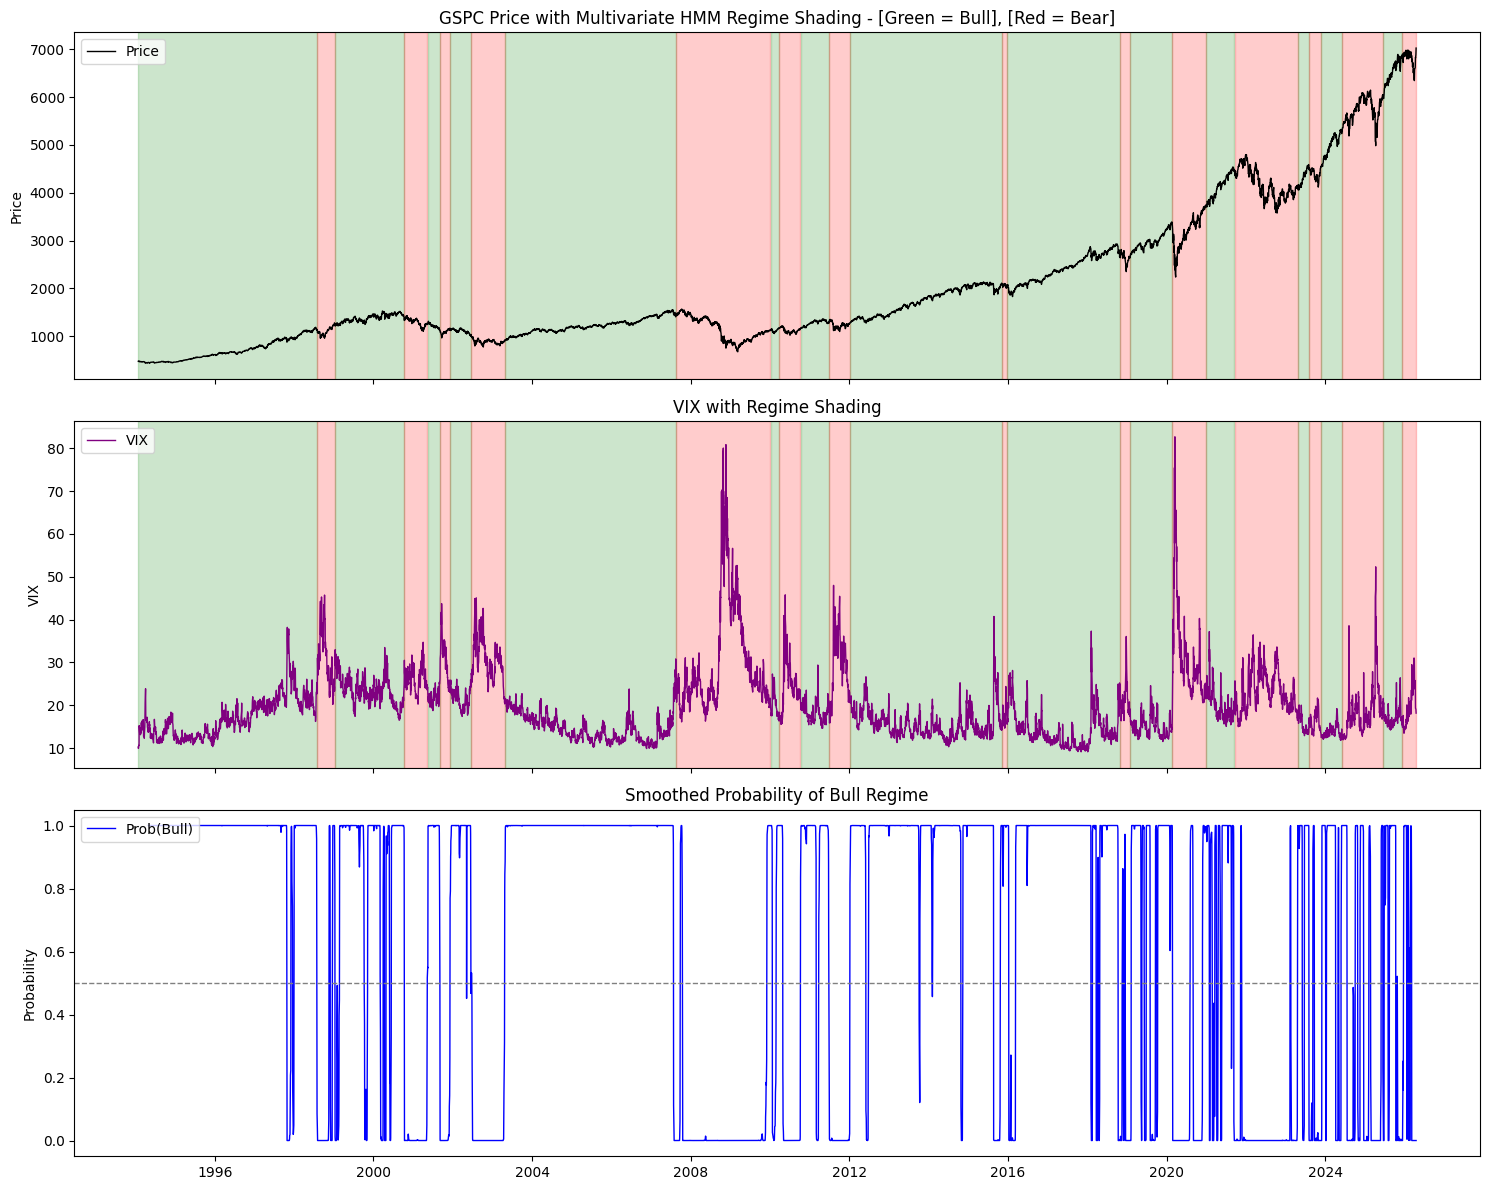

In [72]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
ax1.plot(df['Date'], df[price_col], color='black', linewidth=1, label='Price')
ax1.set_title(f'{price_col} Price with Multivariate HMM Regime Shading - [Green = Bull], [Red = Bear]')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')


df['regime_change'] = (df['regime'] != df['regime'].shift(1)).cumsum()
for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax1.axvspan(start_date, end_date, color=color, alpha=0.2)

# Plot 2: VIX with regime shading
ax2.plot(df['Date'], df['VIX'], color='purple', linewidth=1, label='VIX')
ax2.set_title('VIX with Regime Shading')
ax2.set_ylabel('VIX')
ax2.legend(loc='upper left')

for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax2.axvspan(start_date, end_date, color=color, alpha=0.2)

# Plot 3: Smoothed Probability of Bull Regime
ax3.plot(df['Date'], df['prob_bull'], color='blue', linewidth=1, label='Prob(Bull)')
ax3.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax3.set_title('Smoothed Probability of Bull Regime')
ax3.set_ylabel('Probability')
ax3.set_ylim(-0.05, 1.05)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()
df = df.drop(columns=['regime_change'])

In [73]:
missing_regimes = df['regime'].isna().sum()
assert missing_regimes == 0, f"Error: Found {missing_regimes} missing values in 'regime' column!"
print("Validation passed: No missing values in 'regime' column.")

output_csv = r'../../../data/multivariate_hmm_labeled_dataset.csv'
df.to_csv(output_csv, index=False)
print(f"Dataset saved to {output_csv}")

Validation passed: No missing values in 'regime' column.
Dataset saved to ../../../data/multivariate_hmm_labeled_dataset.csv


In [74]:
# =============================================================================
# PILLAR 2: REAL DATA VALIDATION
# =============================================================================

from scipy import stats

df_work = df.copy()

# --- 1. NBER Recession Dates (official US recession periods) ---
nber_periods = [
    ('1994-01-27', '2001-02-28', 'bull', '1990s Expansion'),
    ('2001-03-01', '2001-11-30', 'bear', '2001 Recession (Dot-Com)'),
    ('2001-12-01', '2007-11-30', 'bull', 'Early 2000s Expansion'),
    ('2007-12-01', '2009-06-30', 'bear', 'Great Recession (GFC)'),
    ('2009-07-01', '2020-01-31', 'bull', 'Post-GFC Expansion'),
    ('2020-02-01', '2020-04-30', 'bear', 'COVID-19 Recession'),
    ('2020-05-01', '2025-12-31', 'bull', 'Post-COVID Recovery'),
]

# Create NBER ground truth column
df_work['nber_regime'] = 'bull'  # default
for start, end, regime, _ in nber_periods:
    mask = (df_work['Date'] >= start) & (df_work['Date'] <= end)
    df_work.loc[mask, 'nber_regime'] = regime

print("NBER Business Cycle Ground Truth")
print("=" * 75)
print(f"{'Period':<35s} {'Expected':<8s} {'Days':>5s} {'Match%':>8s}")
print("-" * 75)

for start, end, expected, name in nber_periods:
    mask = (df_work['Date'] >= start) & (df_work['Date'] <= end)
    if mask.sum() == 0:
        print(f"  {name:<35s}  {'—':>30s} No data in range")
        continue
    period_data = df_work.loc[mask]
    match_pct = (period_data['regime'] == expected).mean() * 100
    n_days = mask.sum()
    print(f"  {name:<35s} {expected:<8s} {n_days:>5d} {match_pct:>7.1f}%")

# Aggregated stats
print(f"\n{'Aggregated':}")
nber_acc = (df_work['regime'] == df_work['nber_regime']).mean()
nber_bear_mask = df_work['nber_regime'] == 'bear'
nber_bear_recall = (df_work.loc[nber_bear_mask, 'regime'] == 'bear').mean() if nber_bear_mask.sum() > 0 else 0
pred_bear_mask = df_work['regime'] == 'bear'
nber_bear_precision = (df_work.loc[pred_bear_mask, 'nber_regime'] == 'bear').mean() if pred_bear_mask.sum() > 0 else 0

from sklearn.metrics import classification_report, confusion_matrix

# --- NBER Aggregated ---
print(f"\nAggregated (vs NBER):")
print(classification_report(df_work['nber_regime'], df_work['regime'],
                            target_names=['bear', 'bull']))
cm = confusion_matrix(df_work['nber_regime'], df_work['regime'], labels=['bear', 'bull'])
print(pd.DataFrame(cm, index=['True Bear', 'True Bull'], columns=['Pred Bear', 'Pred Bull']))


# --- 2. 20% Drawdown Rule ---
peak = df_work[price_col].cummax()
drawdown_from_peak = (df_work[price_col] - peak) / peak

in_bear = False
df_work['drawdown_regime'] = 'bull'
for i in range(len(df_work)):
    if drawdown_from_peak.iloc[i] <= -0.20:
        in_bear = True
    elif in_bear and drawdown_from_peak.iloc[i] >= -0.05:
        in_bear = False
    if in_bear:
        df_work.loc[df_work.index[i], 'drawdown_regime'] = 'bear'

# Identify contiguous drawdown bear periods and label them
dd_changes = (df_work['drawdown_regime'] != df_work['drawdown_regime'].shift(1)).cumsum()
dd_bear_num = 0

print("\n\n20% Drawdown Rule Ground Truth")
print("=" * 75)
print(f"{'Period':<40s} {'Expected':<8s} {'Days':>5s} {'Match%':>8s}")
print("-" * 75)

for _, group in df_work.groupby(dd_changes):
    r = group['drawdown_regime'].iloc[0]
    s = group['Date'].iloc[0].strftime('%Y-%m-%d')
    e = group['Date'].iloc[-1].strftime('%Y-%m-%d')
    n = len(group)
    match_pct = (group['regime'] == r).mean() * 100

    if r == 'bear':
        dd_bear_num += 1
        label = f"Bear {dd_bear_num} ({s} to {e})"
    else:
        label = f"Bull ({s} to {e})"

    # Only print bear periods and bulls longer than 250 days to keep output readable
    if r == 'bear' or n > 250:
        print(f"  {label:<40s} {r:<8s} {n:>5d} {match_pct:>7.1f}%")

# Aggregated stats
print(f"\n{'Aggregated':}")
dd_acc = (df_work['regime'] == df_work['drawdown_regime']).mean()
dd_bear_mask = df_work['drawdown_regime'] == 'bear'
dd_bear_recall = (df_work.loc[dd_bear_mask, 'regime'] == 'bear').mean() if dd_bear_mask.sum() > 0 else 0
dd_pred_bear_mask = df_work['regime'] == 'bear'
dd_bear_precision = (df_work.loc[dd_pred_bear_mask, 'drawdown_regime'] == 'bear').mean() if dd_pred_bear_mask.sum() > 0 else 0

# --- Drawdown Aggregated ---
print(f"\nAggregated (vs 20% Drawdown Rule):")
print(classification_report(df_work['drawdown_regime'], df_work['regime'],
                            target_names=['bear', 'bull']))
cm = confusion_matrix(df_work['drawdown_regime'], df_work['regime'], labels=['bear', 'bull'])
print(pd.DataFrame(cm, index=['True Bear', 'True Bull'], columns=['Pred Bear', 'Pred Bull']))

NBER Business Cycle Ground Truth
Period                              Expected  Days   Match%
---------------------------------------------------------------------------
  1990s Expansion                     bull      1789    88.1%
  2001 Recession (Dot-Com)            bear       188    57.4%
  Early 2000s Expansion               bull      1510    80.9%
  Great Recession (GFC)               bear       397   100.0%
  Post-GFC Expansion                  bull      2665    81.5%
  COVID-19 Recession                  bear        62    79.0%
  Post-COVID Recovery                 bull      1425    34.6%

Aggregated

Aggregated (vs NBER):
              precision    recall  f1-score   support

        bear       0.22      0.86      0.35       647
        bull       0.98      0.73      0.84      7460

    accuracy                           0.74      8107
   macro avg       0.60      0.79      0.59      8107
weighted avg       0.92      0.74      0.80      8107

           Pred Bear  Pred Bull
Tru

In [78]:
# =============================================================================
# STATISTICAL SIGNIFICANCE OF REGIME SEPARATION
# =============================================================================

print("Statistical Significance of GMM Regime Labels")
print("=" * 70)
print("H0: No difference between bull and bear regime distributions")
print("Test: Welch's t-test (unequal variances)\n")

bull_mask = df_work['regime'] == 'bull'
bear_mask = df_work['regime'] == 'bear'

test_features = {
    'Daily Return':     ret_col,
    'VIX':              'VIX',
    'Drawdown':         'Drawdown',
    'RSI_14':           'RSI_14',
    'MACD_Hist':        'MACD_Hist',
}

results = []
for name, col in test_features.items():
    bull_vals = df_work.loc[bull_mask, col].dropna()
    bear_vals = df_work.loc[bear_mask, col].dropna()

    t_stat, p_val = stats.ttest_ind(bull_vals, bear_vals, equal_var=False)

    results.append({
        'Feature': name,
        'Bull Mean': bull_vals.mean(),
        'Bear Mean': bear_vals.mean(),
        'Difference': bull_vals.mean() - bear_vals.mean(),
        't-statistic': t_stat,
        'p-value': p_val,
        'Significant (p<0.01)': 'Yes' if p_val < 0.01 else 'No',
    })

    print(f"  {name:15s} | Bull: {bull_vals.mean():+.6f} | Bear: {bear_vals.mean():+.6f} | "
          f"t={t_stat:+.2f} | p={p_val:.2e} | {'***' if p_val < 0.01 else 'n.s.'}")

# Also test volatility (std of returns in rolling windows)
bull_vol = df_work.loc[bull_mask, ret_col].rolling(21).std().dropna()
bear_vol = df_work.loc[bear_mask, ret_col].rolling(21).std().dropna()
t_stat, p_val = stats.ttest_ind(bull_vol, bear_vol, equal_var=False)
print(f"  {'21d Volatility':15s} | Bull: {bull_vol.mean():+.6f} | Bear: {bear_vol.mean():+.6f} | "
      f"t={t_stat:+.2f} | p={p_val:.2e} | {'***' if p_val < 0.01 else 'n.s.'}")

# Kolmogorov-Smirnov test on return distributions
print("\nKolmogorov-Smirnov D Statistics (Distributional Separation)")
print("=" * 70)
print("Interpretation: D = max CDF gap between bull and bear (0 = identical, 1 = no overlap)\n")

for name, col in test_features.items():
    bull_vals = df_work.loc[bull_mask, col].dropna()
    bear_vals = df_work.loc[bear_mask, col].dropna()
    
    ks_stat, _ = stats.ks_2samp(bull_vals, bear_vals)
    print(f"  {name:15s} | D={ks_stat:.4f}")

Statistical Significance of GMM Regime Labels
H0: No difference between bull and bear regime distributions
Test: Welch's t-test (unequal variances)

  Daily Return    | Bull: +0.000557 | Bear: +0.000063 | t=+1.40 | p=1.62e-01 | n.s.
  VIX             | Bull: +16.592044 | Bear: +26.603408 | t=-50.37 | p=0.00e+00 | ***
  Drawdown        | Bull: -0.079170 | Bear: -0.179066 | t=+31.75 | p=1.74e-195 | ***
  RSI_14          | Bull: +56.309777 | Bear: +50.589415 | t=+21.31 | p=2.11e-96 | ***
  MACD_Hist       | Bull: -0.128470 | Bear: +0.263240 | t=-1.48 | p=1.38e-01 | n.s.
  21d Volatility  | Bull: +0.007760 | Bear: +0.014927 | t=-41.85 | p=9.94e-299 | ***

Kolmogorov-Smirnov D Statistics (Distributional Separation)
Interpretation: D = max CDF gap between bull and bear (0 = identical, 1 = no overlap)

  Daily Return    | D=0.1315
  VIX             | D=0.5564
  Drawdown        | D=0.3662
  RSI_14          | D=0.2004
  MACD_Hist       | D=0.2002


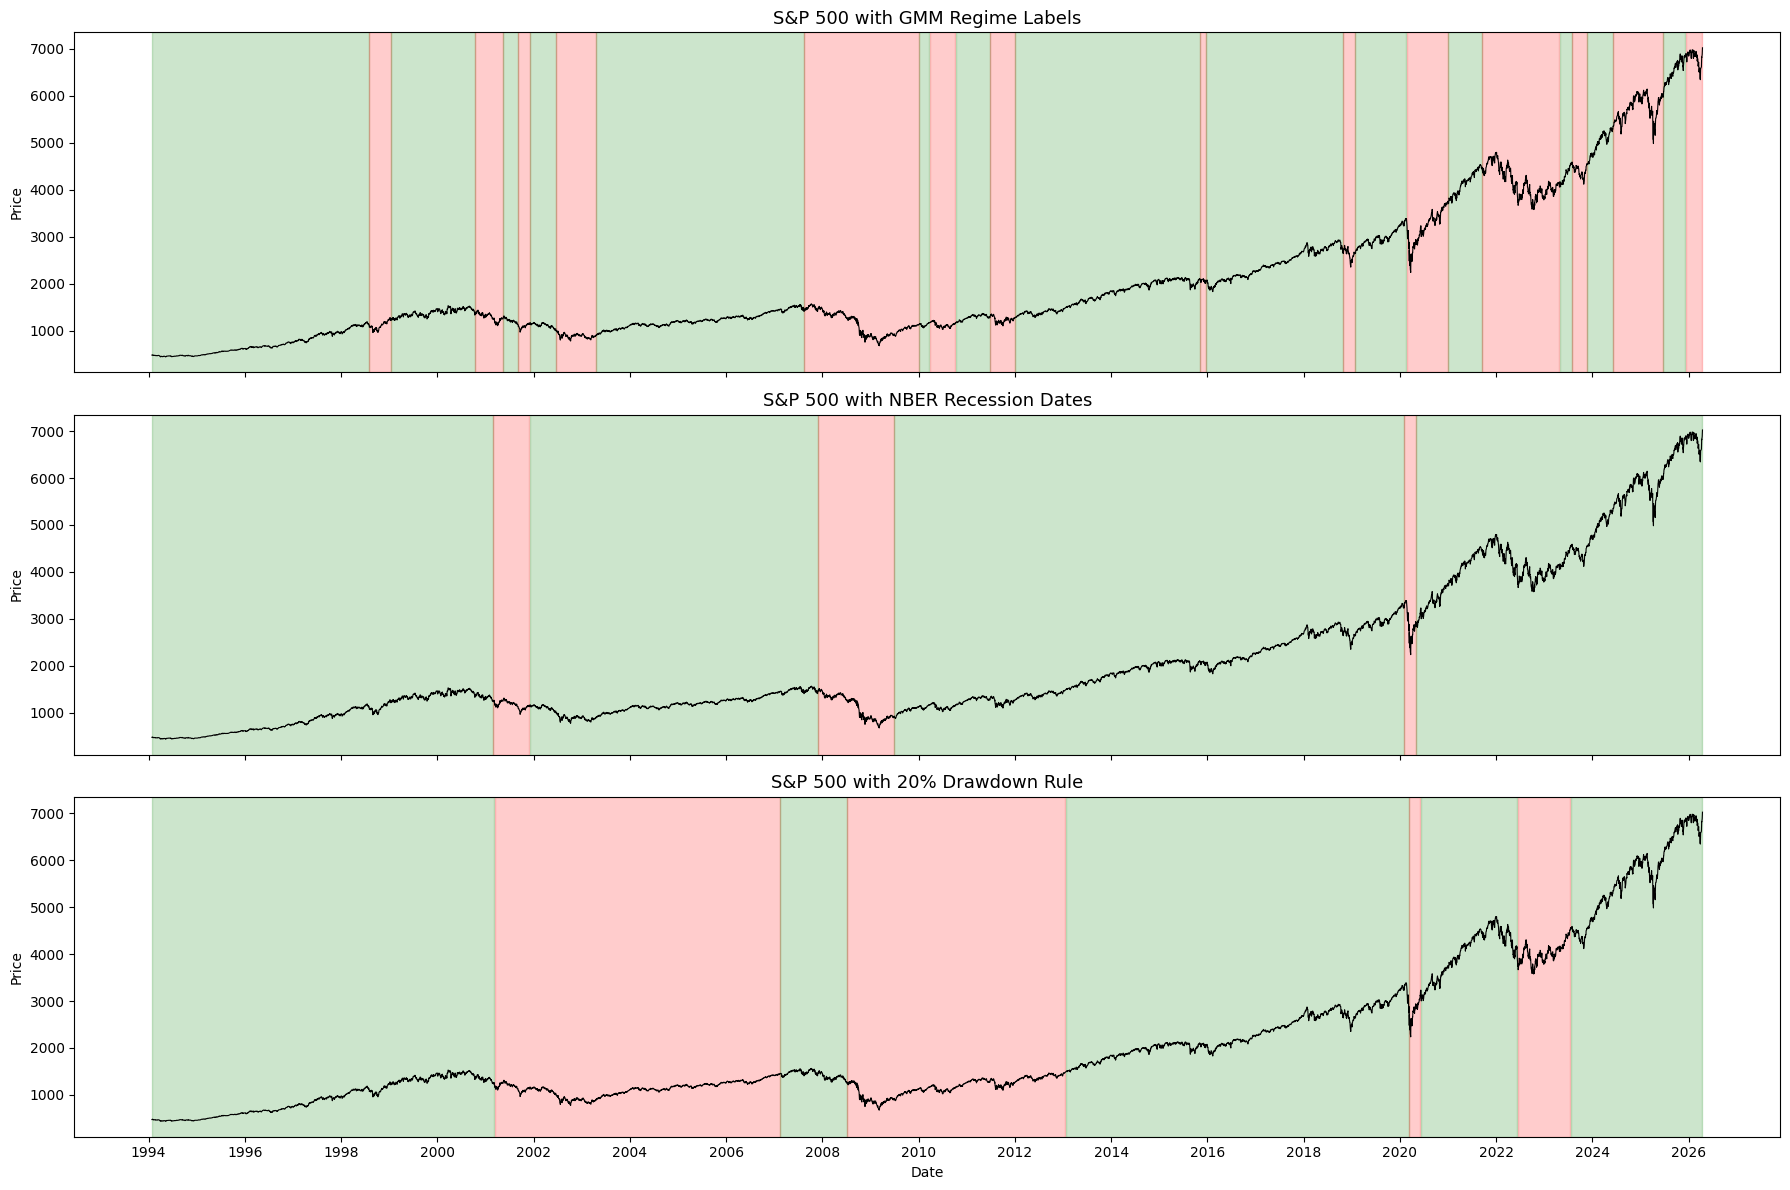

In [76]:
# =============================================================================
# VISUAL COMPARISON: GMM vs NBER vs 20% DRAWDOWN
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

for ax, (label, regime_col) in zip(axes, [
    ('GMM Regime Labels', 'regime'),
    ('NBER Recession Dates', 'nber_regime'),
    ('20% Drawdown Rule', 'drawdown_regime'),
]):
    ax.plot(df_work['Date'], df_work[price_col], color='black', linewidth=0.8)
    ax.set_title(f'S&P 500 with {label}', fontsize=13)
    ax.set_ylabel('Price')

    changes = (df_work[regime_col] != df_work[regime_col].shift(1)).cumsum()
    for _, group in df_work.groupby(changes):
        s = group['Date'].iloc[0]
        e = group['Date'].iloc[-1]
        r = group[regime_col].iloc[0]
        ax.axvspan(s, e, color='green' if r == 'bull' else 'red', alpha=0.2)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [77]:
def cohens_d(group_a, group_b):
    """Compute Cohen's d (pooled std)."""
    na, nb = len(group_a), len(group_b)
    var_a, var_b = group_a.var(), group_b.var()
    pooled_std = np.sqrt(((na - 1) * var_a + (nb - 1) * var_b) / (na + nb - 2))
    return (group_a.mean() - group_b.mean()) / pooled_std

print("Regime Separation: Effect Sizes (Cohen's d)")
print("=" * 70)
print("Interpretation: |d| < 0.2 negligible, 0.2-0.5 small,")
print("                0.5-0.8 medium, > 0.8 large\n")

bull_mask = df_work['regime'] == 'bull'
bear_mask = df_work['regime'] == 'bear'

test_features = {
    'Daily Return':     ret_col,
    'VIX':              'VIX',
    'Drawdown':         'Drawdown',
    'RSI_14':           'RSI_14',
    'MACD_Hist':        'MACD_Hist',
}

for name, col in test_features.items():
    bull_vals = df_work.loc[bull_mask, col].dropna()
    bear_vals = df_work.loc[bear_mask, col].dropna()
    
    d = cohens_d(bull_vals, bear_vals)
    
    if abs(d) >= 0.8:
        magnitude = 'LARGE'
    elif abs(d) >= 0.5:
        magnitude = 'MEDIUM'
    elif abs(d) >= 0.2:
        magnitude = 'SMALL'
    else:
        magnitude = 'NEGLIGIBLE'
    
    print(f"  {name:15s} | Bull: {bull_vals.mean():+.6f} | Bear: {bear_vals.mean():+.6f} | "
          f"d={d:+.3f} | {magnitude}")

Regime Separation: Effect Sizes (Cohen's d)
Interpretation: |d| < 0.2 negligible, 0.2-0.5 small,
                0.5-0.8 medium, > 0.8 large

  Daily Return    | Bull: +0.000557 | Bear: +0.000063 | d=+0.042 | NEGLIGIBLE
  VIX             | Bull: +16.592044 | Bear: +26.603408 | d=-1.537 | LARGE
  Drawdown        | Bull: -0.079170 | Bear: -0.179066 | d=+0.875 | LARGE
  RSI_14          | Bull: +56.309777 | Bear: +50.589415 | d=+0.515 | MEDIUM
  MACD_Hist       | Bull: -0.128470 | Bear: +0.263240 | d=-0.048 | NEGLIGIBLE
